In [11]:
from langgraph.graph import StateGraph,START, END
from langchain_google_genai import ChatGoogleGenerativeAI
from typing import TypedDict, Annotated
from dotenv import load_dotenv
from langchain_core.messages import BaseMessage, HumanMessage

In [12]:
load_dotenv()

True

In [13]:
model = ChatGoogleGenerativeAI(
    model = 'gemini-3.5-flash'
)

In [14]:
from langgraph.graph.message import add_messages

class chat(TypedDict):

    message : Annotated[list[BaseMessage],add_messages]

In [15]:
def node(state: chat):

    message = state['message']

    response = model.invoke(message)

    return {'message' : [response]}

In [26]:
graph = StateGraph(chat)

graph.add_node('node',node)

graph.add_edge(START,'node')
graph.add_edge('node', END)

workflow = graph.compile()

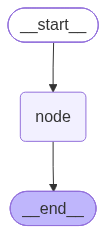

In [17]:
graph.compile()

In [29]:
initial = {
    "message": [
        HumanMessage(content="capital of India")
    ]
}
workflow.invoke(initial)['message'][-2].content

'capital of India'

In [33]:
while True:

    user_message = input('Type Here : ')

    print('User:', user_message)

    if user_message.strip().lower() in ['exit','quit', 'bye']:
        break

    response =workflow.invoke({'message' : [HumanMessage(content=user_message)]})

    print('AI:', response['message'][-1].content[0]['text'])

User: hi
AI: Hello! How can I help you today?
User: yooo
AI: Yoooo! What's up? How's it going?
User: bye
